In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
df = pd.read_csv('Surveydata.csv', encoding='ISO-8859-1')
df

,Age group,Flight Frequency,Online Ad Influence,Influencing_Platform,Follow_Airlines Social Media,PromoPlatform,Imp_Promo,AppWebBooking_Ryanair,AppWebBooking_EasyJet,AppWebBooking_British Airways,...,ComfortRating_Ryanair,ComfortRating_EasyJet,ComfortRating_British Airways,ComfortRating_Aer Lingus,Customer Support_Ryanair,Customer Support_EasyJet,Customer Support_British Airways,Customer Support_Aer Lingus,Loyalty programs_Airline,Rating_LikelyEngagePromoCampaigns
0,1824,1-3 times,Yes,Instagram,Ryanair,Instagram,Very important,4,3,3,...,4,3,3,5,4,3,3,5,Yes,4
1,2534,1-3 times,Yes,Instagram,NaN,Instagram,Very important,3,3,3,...,4,3,4,3,4,3,4,3,No,3
2,1824,1-3 times,Yes,Google Ads,NaN,Google/YouTube Ads,Not important,2,3,3,...,3,1,1,2,3,2,2,2,No,1
3,1824,1-3 times,No,Online Travel Agents like Skyscanner,NaN,Google/YouTube Ads,Not important,3,3,3,...,2,3,3,4,2,3,3,3,No,1
4,2534,1-3 times,No,Online Travel Agents like Skyscanner,Ryanair,Facebook,Very important,4,4,4,...,4,4,4,4,4,4,4,4,Maybe,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203,45+,1-3 times,Yes,Airline Website,NaN,Facebook,Sometimes,4,3,4,...,4,3,4,4,5,3,5,5,No,3
204,2534,46 times,No,Airline Website,NaN,Instagram,Sometimes,5,5,5,...,5,5,5,5,2,2,2,2,Yes,5
205,2534,1-3 times,No,Online Travel Agents like Skyscanner,British Airways,Google/YouTube Ads,Not important,3,3,3,...,3,3,3,3,3,3,3,3,No,3
206,1824,1-3 times,No,Online Travel Agents like Skyscanner,NaN,Instagram,Sometimes,4,3,3,...,4,3,3,5,3,3,3,3,No,2


In [7]:
# Most Effective Digital Marketing Channels

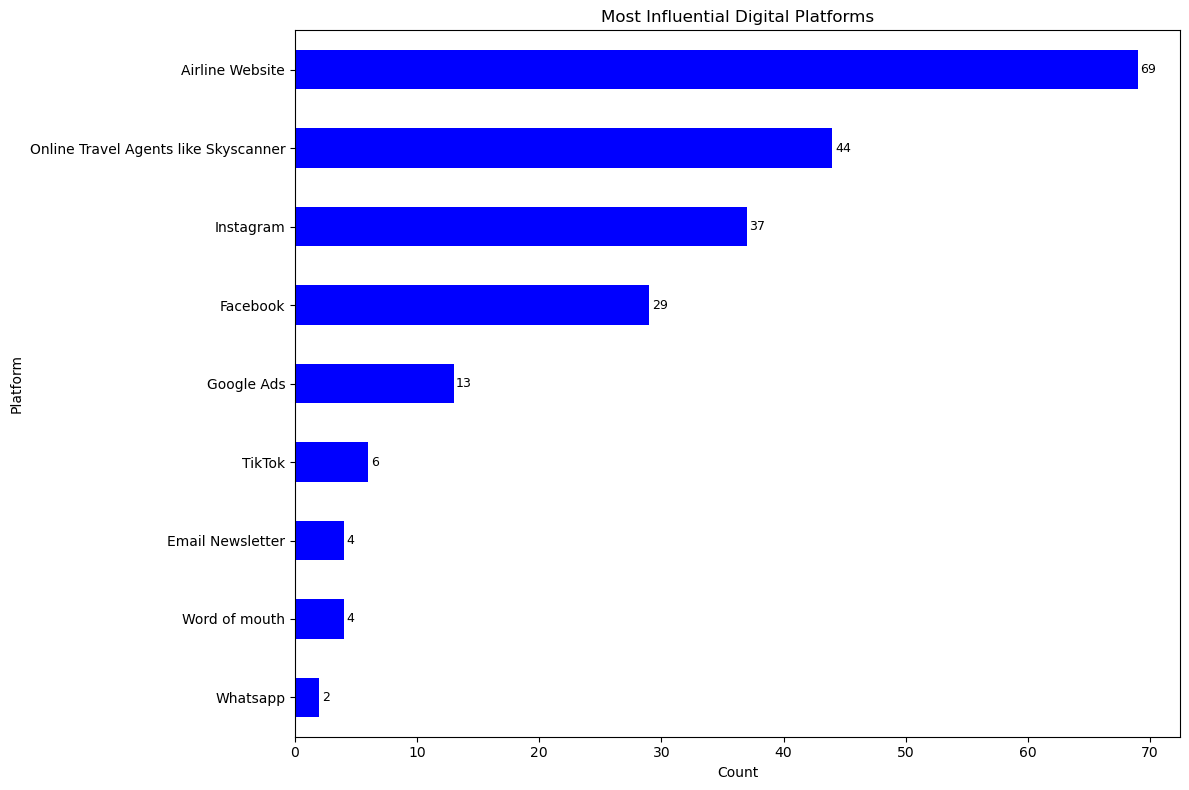

In [32]:
# Clean column names
df.columns = df.columns.str.strip()

# Get counts sorted descending (highest first)
platform_counts = df['Influencing_Platform'].value_counts().sort_values(ascending=True)  # ascending=True for horizontal barh to have highest on top

# Plot horizontal bar chart with sorted counts
plt.figure(figsize=(12, 8))
ax = platform_counts.plot(kind='barh', color='blue')

plt.title('Most Influential Digital Platforms')
plt.xlabel('Count')       # Count on X-axis
plt.ylabel('Platform')    # Platform names on Y-axis

# Add value labels at the end of each bar
for i, v in enumerate(platform_counts):
    ax.text(v + 0.2, i, str(v), va='center', fontsize=9)

plt.tight_layout()

# Save the figure to a file
plt.savefig('influential_platforms_bar_chart.png', dpi=300, bbox_inches='tight')

plt.show()

In [33]:
# Impact of Personalised Marketing on Engagement and Bookings

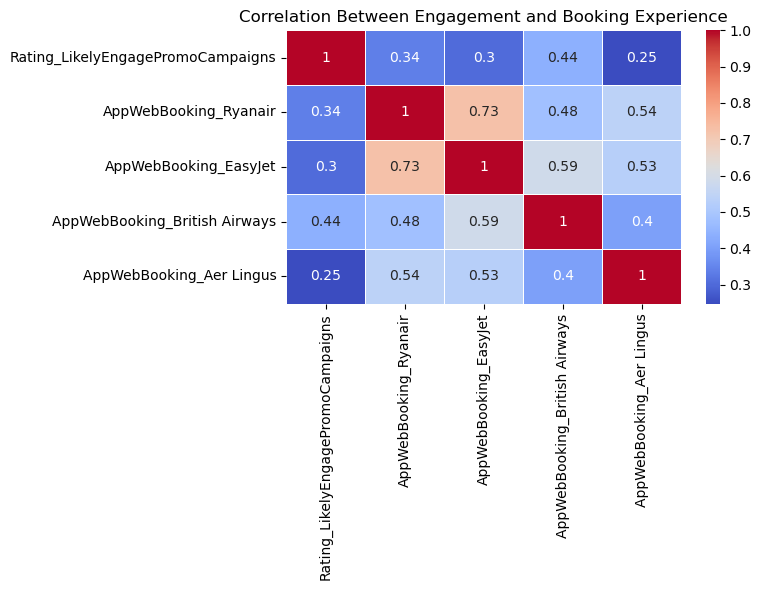

In [38]:
df.columns = df.columns.str.strip()  # Clean column names

# --- Plot 2: Correlation Matrix (Heatmap) ---
corr_df = df[['Rating_LikelyEngagePromoCampaigns'] + booking_cols]
plt.figure(figsize=(8,6))
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Between Engagement and Booking Experience')
plt.tight_layout()
plt.savefig('heatmap_correlation_engagement_booking.png', dpi=300)
plt.show()

In [39]:
# Loyalty Programs and Customer Retention

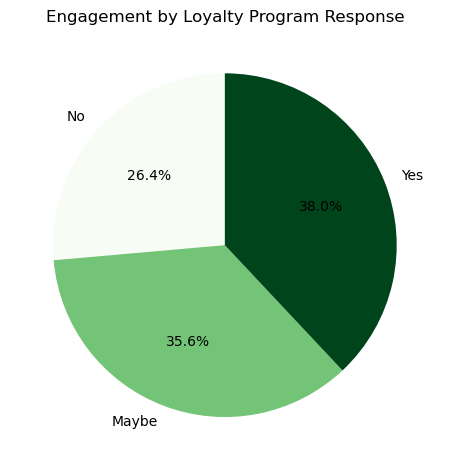

In [57]:
# Create the data series manually
loyalty_engagement = pd.Series([26.4, 35.6, 38], index=['No', 'Maybe', 'Yes'])

loyalty_engagement.plot(kind='pie', autopct='%1.1f%%', startangle=90, colormap='Greens')
plt.title('Engagement by Loyalty Program Response')
plt.ylabel('')  # Hide y-axis label
plt.tight_layout()
plt.savefig('engagement_pie_chart.png', dpi=300)
plt.show()

In [58]:
# Age Group vs. Booking Preferences

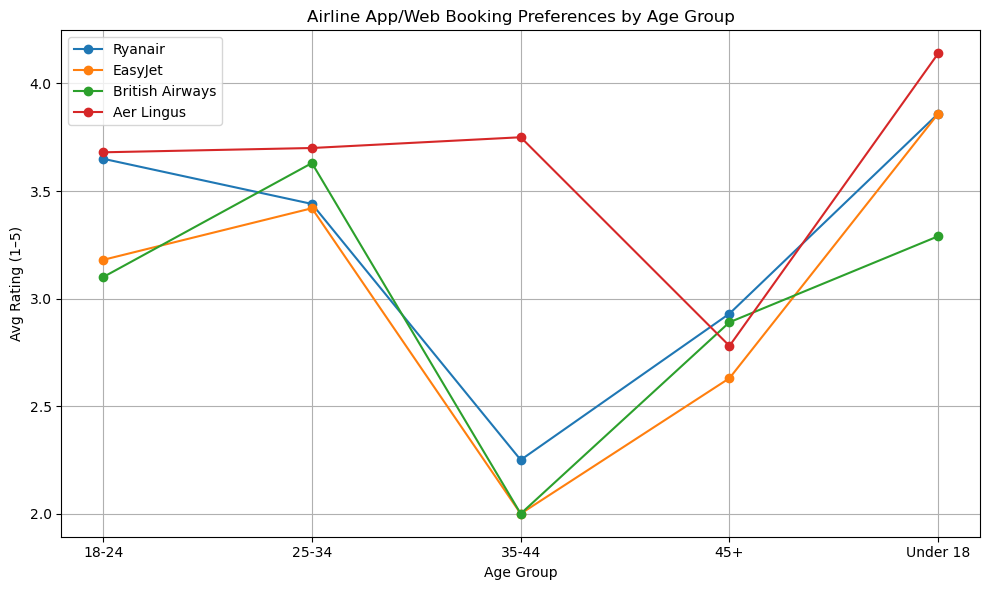

In [65]:
# Fix encoding issues in 'Age group'
df['Age group'] = df['Age group'].str.replace('', '-')

# Define booking-related columns
booking_columns = [
    'AppWebBooking_Ryanair',
    'AppWebBooking_EasyJet',
    'AppWebBooking_British Airways',
    'AppWebBooking_Aer Lingus'
]

# Group by 'Age group' and calculate the mean for each booking platform
age_group_booking = df.groupby('Age group')[booking_columns].mean().round(2)

plt.figure(figsize=(10, 6))
for col in booking_columns:
    plt.plot(age_group_booking.index, age_group_booking[col], marker='o', label=col.replace("AppWebBooking_", ''))

plt.title('Airline App/Web Booking Preferences by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Avg Rating (1–5)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('booking_preferences_by_age.png', dpi=300)
plt.show()

In [66]:
# Followed_Airline_SocialMedia

C:\Users\HP\AppData\Local\Temp\ipykernel_22284\1526447111.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


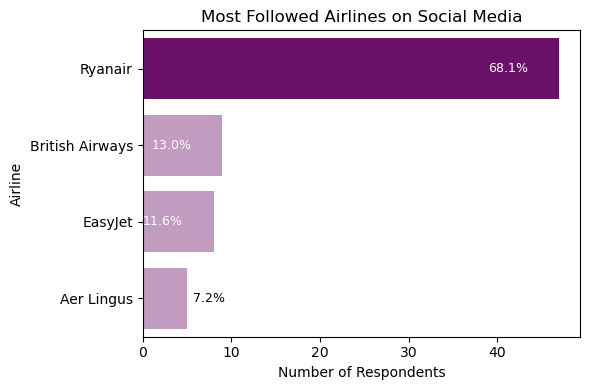

In [91]:
df.columns = df.columns.str.strip()

# Count most followed airlines on social media
social_follow_counts = df['Follow_Airlines Social Media'].value_counts().sort_values(ascending=False)

# Calculate percentages
total = social_follow_counts.sum()
percentages = (social_follow_counts / total * 100).round(1)

# Identify index of the highest percentage
max_idx = social_follow_counts.idxmax()

# Create custom colors: dark color for the highest, lighter for others
colors = ['#7a0177' if idx == max_idx else '#c994c7' for idx in social_follow_counts.index]

# Plot
plt.figure(figsize=(6, 4))
ax = sns.barplot(
    x=social_follow_counts.values,
    y=social_follow_counts.index,
    palette=colors,
    orient='h'
)

# Add percentage labels inside the bars
for i, (value, percent) in enumerate(zip(social_follow_counts.values, percentages)):
    # Align text left or right depending on bar length
    if value > total * 0.1:
        ax.text(value - total * 0.05, i, f'{percent}%', va='center', ha='right', color='white', fontsize=9)
    else:
        ax.text(value + total * 0.01, i, f'{percent}%', va='center', ha='left', color='black', fontsize=9)

plt.title('Most Followed Airlines on Social Media')
plt.xlabel('Number of Respondents')
plt.ylabel('Airline')
plt.tight_layout()
plt.savefig('most_followed_airlines_social.png', dpi=300)
plt.show()

In [92]:
# age group reports the highest influence from online ads

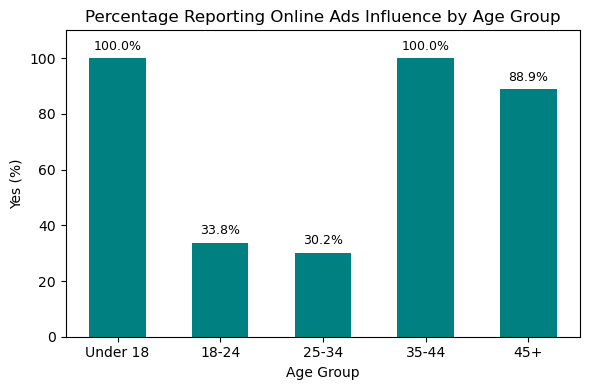

In [99]:
df.columns = df.columns.str.strip()
df['Age group'] = df['Age group'].str.strip()

# ── Aggregate ──────────────────────────────────────────────────────────────────
summary = (
    df.groupby('Age group')['Online Ad Influence']
      .agg(
          Sample_Size='count',
          Yes_Count=lambda x: (x == 'Yes').sum()
      )
)
summary['Yes %'] = (summary['Yes_Count'] / summary['Sample_Size']) * 100
summary = summary.reset_index()

# optional: logical order for plotting
age_order = ['Under 18', '18-24', '25-34', '35-44', '45+']
summary['Age group'] = pd.Categorical(summary['Age group'],
                                      categories=age_order,
                                      ordered=True)
summary = summary.sort_values('Age group')

# ── Plot ───────────────────────────────────────────────────────────────────────
plt.figure(figsize=(6, 4))

bars = plt.bar(summary['Age group'],
               summary['Yes %'],
               color='teal',
               width=0.55)

# Add percentage labels above each bar
for bar, pct in zip(bars, summary['Yes %']):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 2,
             f'{pct:.1f}%',
             ha='center', va='bottom', fontsize=9)

plt.title('Percentage Reporting Online Ads Influence by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Yes (%)')
plt.ylim(0, summary['Yes %'].max() + 10)
plt.xticks(rotation=0)

# Save the figure as an image
plt.tight_layout()
plt.savefig('online_ad_influence_by_age.png', dpi=300)  # ← Save before show

plt.show()

In [100]:
# social media ads effective in converting engagemnt into bookings

C:\Users\HP\AppData\Local\Temp\ipykernel_22284\710542132.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  overall['Primary_Platform'] = overall['Influencing_Platform'].apply(primary_platform)


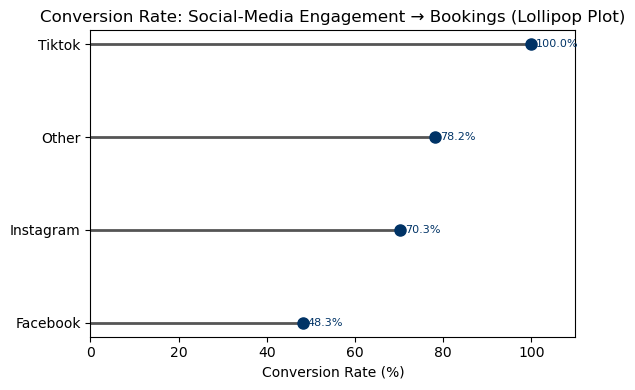

In [103]:
df.columns = df.columns.str.strip()                         # trim stray spaces

# 2 ─ Flag rows that engaged with a social‑media ad
social_media_keywords = [
    'instagram', 'facebook', 'tiktok', 'twitter', 'linkedin', 'youtube',
    'snapchat', 'pinterest', 'reddit'
]

# lowercase helpers
df['Influencing_Platform'] = df['Influencing_Platform'].str.lower().fillna('')
df['PromoPlatform']        = df['PromoPlatform'].str.lower().fillna('')

df['Engaged_Social_Ad'] = (
    df['Influencing_Platform'].apply(
        lambda txt: any(k in txt for k in social_media_keywords)
    ) |
    df['PromoPlatform'].apply(
        lambda txt: any(k in txt for k in social_media_keywords)
    )
)

# 3 ─ Flag rows that converted into a booking (rating ≥ 4 on any airline’s “App/Web Booking” scale)
booking_cols = [c for c in df.columns if c.startswith('AppWebBooking_')]

def converted(row) -> bool:
    """Return True if the respondent gave ≥4 on ANY App/Web booking rating."""
    for col in booking_cols:
        try:
            if pd.notna(row[col]) and float(row[col]) >= 4:
                return True
        except ValueError:
            pass                       # ignore non‑numeric cells
    return False

df['Converted'] = df.apply(converted, axis=1)

# 4 ─ Overall conversion rate among those influenced by social‑media ads
overall = df[df['Engaged_Social_Ad']]
overall_conv_rate = round(overall['Converted'].mean() * 100, 1)

# 5 ─ Conversion rate broken down by primary social platform
def primary_platform(text: str) -> str:
    for kw in social_media_keywords:
        if kw in text:
            return kw.capitalize()
    return 'Other'

overall['Primary_Platform'] = overall['Influencing_Platform'].apply(primary_platform)

platform_summary = (
    overall.groupby('Primary_Platform')['Converted']
           .agg(Engaged='count', Conversions='sum')
           .assign(Conversion_Rate=lambda t: round(t['Conversions'] / t['Engaged'] * 100, 1))
           .reset_index()
           .sort_values('Conversion_Rate', ascending=False)
)

# 6 ─ Lollipop plot of conversion rate per platform (dark colour)
plt.figure(figsize=(6, 4))

# Build y‑axis positions
y_pos = range(len(platform_summary))
conversion_rates = platform_summary['Conversion_Rate']

# Draw stems
plt.hlines(y=y_pos, xmin=0, xmax=conversion_rates,
           color='#555555', linewidth=2)     # dark grey stems

# Draw lollipop heads
plt.plot(conversion_rates, y_pos, 'o',
         markersize=8, color='#003366')     # dark blue dots

# Annotate with percentages
for y, x in zip(y_pos, conversion_rates):
    plt.text(x + 1, y, f'{x}%', va='center',
             fontsize=8, color='#003366')    # same dark blue for text

# Formatting
plt.yticks(y_pos, platform_summary['Primary_Platform'])
plt.xlabel('Conversion Rate (%)')
plt.title('Conversion Rate: Social‑Media Engagement → Bookings (Lollipop Plot)')
plt.xlim(0, conversion_rates.max() + 10)
plt.gca().invert_yaxis()  # highest conversion at the top
plt.tight_layout()

# 7 ─ Save and show the figure
plt.savefig('social_media_conversion_lollipop.png', dpi=300)
plt.show()

In [ ]:
# Real-time digital updates, VA_Chatbots, RecommendAirline_DigitalExp

In [104]:
df.columns = df.columns.str.strip()

# Select relevant columns
df_filtered = df[[
    'Real-time digital updates',
    'VA_Chatbots',
    'RecommendAirline_DigitalExp',
    'Best InFlight Exp_Airline'
]].copy()

# Clean whitespace and lowercase text for consistency
df_filtered.columns = df_filtered.columns.str.strip()
df_filtered['Best InFlight Exp_Airline'] = df_filtered['Best InFlight Exp_Airline'].str.strip()
df_filtered = df_filtered.dropna(subset=['Best InFlight Exp_Airline'])

# Focus on 4 key airlines
main_airlines = ['Aer Lingus', 'Ryanair', 'EasyJet', 'British Airways']
df_main = df_filtered[df_filtered['Best InFlight Exp_Airline'].isin(main_airlines)]

# Helper function to get percentage distributions
def value_distribution(df, column, airline):
    dist = (
        df[df['Best InFlight Exp_Airline'] == airline][column]
        .value_counts(normalize=True) * 100
    ).round(1)
    return dist.to_frame(name=airline)

# Generate summaries
columns_to_analyze = [
    'Real-time digital updates',
    'VA_Chatbots',
    'RecommendAirline_DigitalExp'
]

# Collect results
summary_tables = {}
for col in columns_to_analyze:
    summary = pd.concat(
        [value_distribution(df_main, col, airline) for airline in main_airlines],
        axis=1
    ).fillna(0)
    summary_tables[col] = summary

summary_tables

{'Real-time digital updates':                            Aer Lingus  Ryanair  EasyJet  British Airways
 Real-time digital updates                                               
 Yes                              78.3     59.5     40.0             50.0
 Sometimes                        18.1     31.0     40.0             24.0
 No                                3.6      9.5     20.0             26.0,
 'VA_Chatbots':                          Aer Lingus  Ryanair  EasyJet  British Airways
 VA_Chatbots                                                           
 No                             66.3     40.5     20.0             52.0
 Yes, and it was helpful        21.7     38.1     20.0             28.0
 Yes, but not helpful           12.0     21.4     60.0             20.0,
 'RecommendAirline_DigitalExp':                              Aer Lingus  Ryanair  EasyJet  British Airways
 RecommendAirline_DigitalExp                                               
 Probably yes                       43.4 

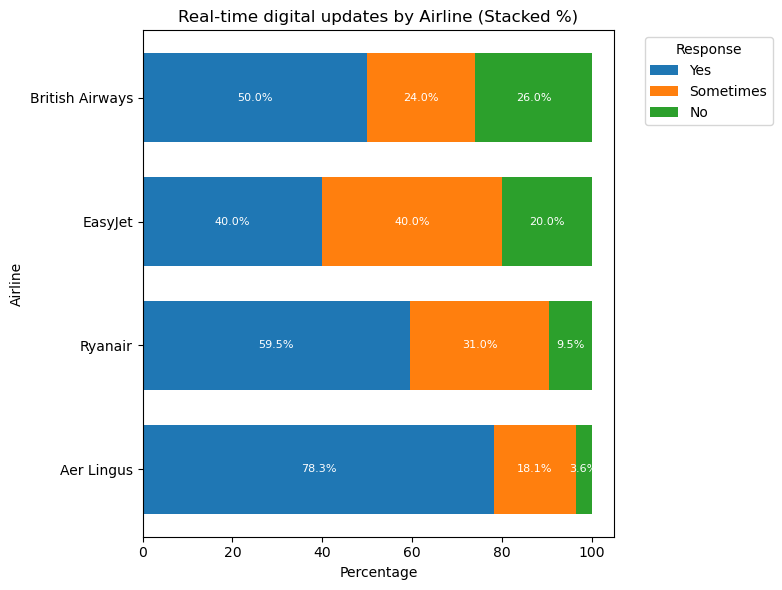

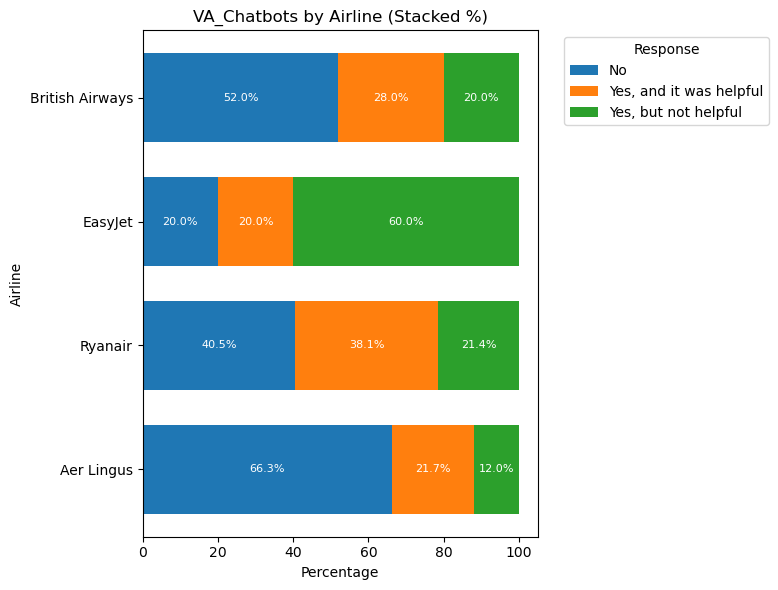

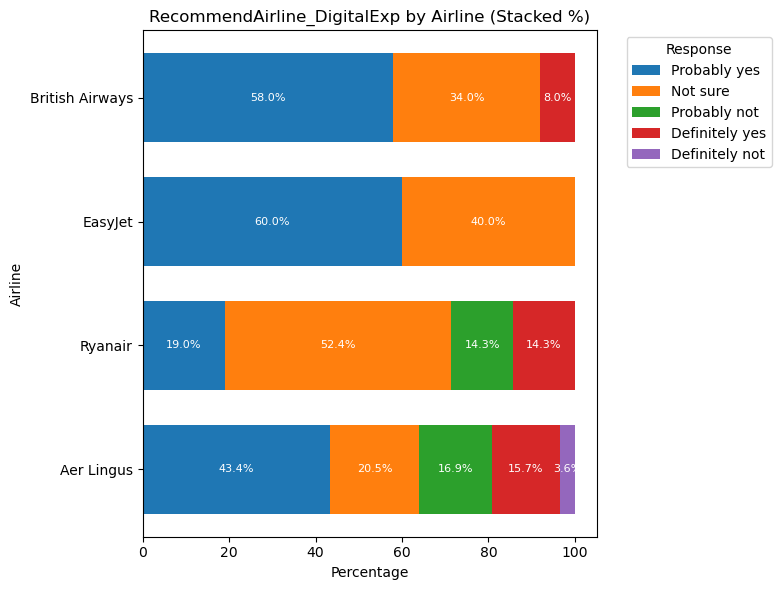

In [115]:
df.columns = df.columns.str.strip()

# Filter relevant columns
df_filtered = df[[
    'Real-time digital updates',
    'VA_Chatbots',
    'RecommendAirline_DigitalExp',
    'Best InFlight Exp_Airline'
]].copy()

df_filtered.columns = df_filtered.columns.str.strip()
df_filtered['Best InFlight Exp_Airline'] = df_filtered['Best InFlight Exp_Airline'].str.strip()

# Main airlines to analyze
main_airlines = ['Aer Lingus', 'Ryanair', 'EasyJet', 'British Airways']
df_main = df_filtered[df_filtered['Best InFlight Exp_Airline'].isin(main_airlines)]

# Helper: compute % distribution per column
def value_distribution(df, column, airline):
    dist = (
        df[df['Best InFlight Exp_Airline'] == airline][column]
        .value_counts(normalize=True) * 100
    ).round(1)
    return dist.to_frame(name=airline)

# Summary tables
columns_to_analyze = [
    'Real-time digital updates',
    'VA_Chatbots',
    'RecommendAirline_DigitalExp'
]

summary_tables = {}
for col in columns_to_analyze:
    summary = pd.concat(
        [value_distribution(df_main, col, airline) for airline in main_airlines],
        axis=1
    ).fillna(0)
    summary_tables[col] = summary

# Plotting
colors = plt.get_cmap('tab10').colors

for category, table in summary_tables.items():
    plt.figure(figsize=(8, 6))

    airlines = table.columns.tolist()
    y_positions = np.arange(len(airlines)) * 0.35 # reduce spacing between bars
    bar_height = 0.25 # reduced bar thickness

    bottom = [0] * len(airlines)
    for i, response in enumerate(table.index):
        values = table.loc[response]
        bars = plt.barh(
            y=y_positions,
            width=values,
            left=bottom,
            height=bar_height,
            label=response,
            color=colors[i % len(colors)]
        )

        # Add percentage labels
        for bar, pct in zip(bars, values):
            if pct > 2:  # avoid clutter for very small %s
                plt.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + bar.get_height() / 2,
                    f"{pct:.1f}%",
                    ha='center',
                    va='center',
                    fontsize=8,
                    color='white'
                )

        bottom = [sum(x) for x in zip(bottom, values)]

    plt.yticks(ticks=y_positions, labels=airlines)
    plt.title(f"{category} by Airline (Stacked %)")
    plt.xlabel('Percentage')
    plt.ylabel('Airline')
    plt.legend(title='Response', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(False)
    plt.tight_layout()
    plt.savefig(f"{category.replace(' ', '_').lower()}_stacked_bar_with_labels.png", dpi=300)
    plt.show()

In [ ]:
# comfort rating

C:\Users\HP\AppData\Local\Temp\ipykernel_22284\1267638626.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\HP\AppData\Local\Temp\ipykernel_22284\1267638626.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


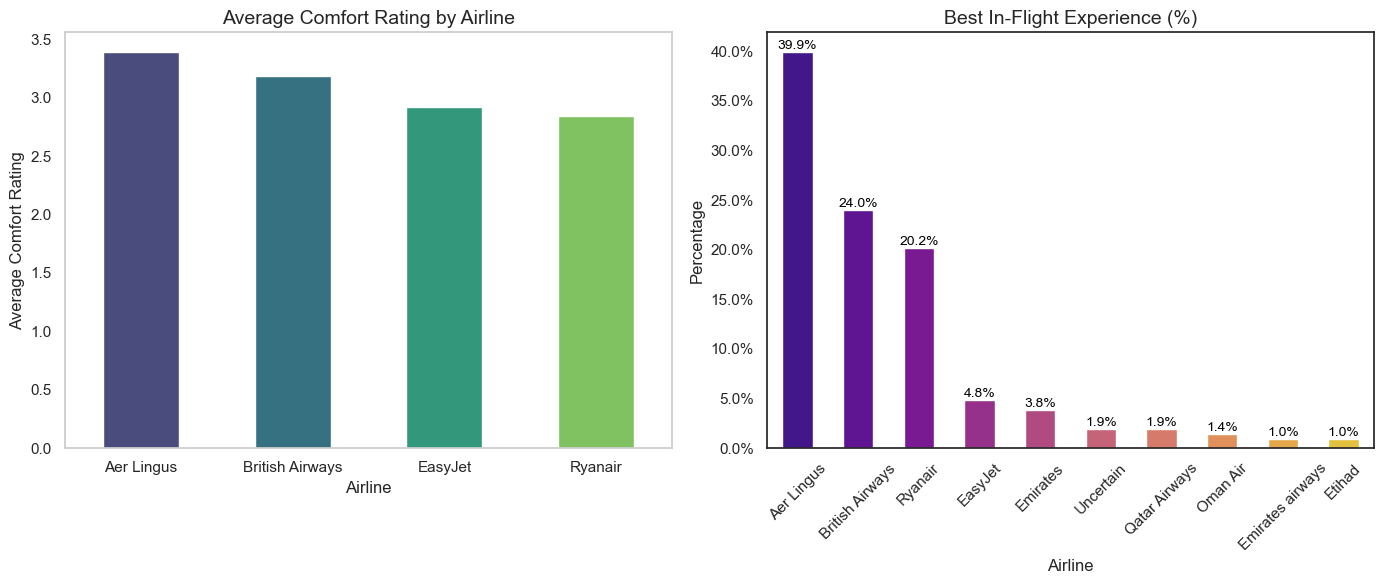

In [125]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
from tabulate import tabulate

# Load the dataset
file_path = "Surveydata.csv"  # Use full path if needed
df = pd.read_csv(file_path, encoding='ISO-8859-1')

# Relevant comfort rating columns
comfort_columns = [
    'ComfortRating_Ryanair',
    'ComfortRating_EasyJet',
    'ComfortRating_British Airways',
    'ComfortRating_Aer Lingus'
]

# Convert to numeric values
df[comfort_columns] = df[comfort_columns].apply(pd.to_numeric, errors='coerce')

# Compute average comfort ratings
comfort_means = df[comfort_columns].mean()
comfort_means.index = comfort_means.index.str.replace("ComfortRating_", "")

# Build average comfort rating table
avg_comfort_table = comfort_means.reset_index()
avg_comfort_table.columns = ['Airline', 'Average_Comfort_Rating']
avg_comfort_table.sort_values(by='Average_Comfort_Rating', ascending=False, inplace=True)
avg_comfort_table.reset_index(drop=True, inplace=True)

# Compute best inflight experience percentages
best_inflight_counts = df['Best InFlight Exp_Airline'].value_counts()
best_inflight_percent = (best_inflight_counts / best_inflight_counts.sum()) * 100
best_inflight_df = best_inflight_percent.reset_index()
best_inflight_df.columns = ['Airline', 'Percentage']

plt.figure(figsize=(14, 6))
sns.set(style="whitegrid")  # Still using whitegrid for consistent styling

# Plot average comfort ratings (WITHOUT background lines)
plt.subplot(1, 2, 1)
sns.set_style("white")  # Set white background to remove gridlines
sns.barplot(
    x='Airline',
    y='Average_Comfort_Rating',
    data=avg_comfort_table,
    palette='viridis',
    width=0.5
)
plt.title("Average Comfort Rating by Airline", fontsize=14)
plt.ylabel("Average Comfort Rating")
plt.xlabel("Airline")
plt.grid(False)  # Ensure gridlines are turned off

# Plot Best In-Flight Experience with percentage (retain grid for clarity)
plt.subplot(1, 2, 2)
sns.set_style("whitegrid")  # Reapply grid for second chart
ax = sns.barplot(
    x='Airline',
    y='Percentage',
    data=best_inflight_df,
    palette='plasma',
    width=0.5
)
plt.title("Best In-Flight Experience (%)", fontsize=14)
plt.ylabel("Percentage")
plt.xlabel("Airline")
plt.xticks(rotation=45)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# Add percentage labels to bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.1f}%',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10, color='black')

plt.tight_layout()
plt.savefig("best_inflight_experience_chart.png", dpi=300, bbox_inches='tight')
plt.savefig("average_comfort_rating_chart.png", dpi=300, bbox_inches='tight')
plt.show()


In [124]:
# Prepare and round data (no index in final image)
styled_df = avg_comfort_table.copy()
styled_df['Average_Comfort_Rating'] = styled_df['Average_Comfort_Rating'].round(2)

# Plot setup
fig, ax = plt.subplots(figsize=(8, 2 + 0.5 * len(styled_df)))
ax.axis('off')

# Table data and headers (no index column)
table_data = styled_df.values.tolist()
column_labels = styled_df.columns.tolist()

# Create the table
table = ax.table(
    cellText=table_data,
    colLabels=column_labels,
    cellLoc='center',
    colLoc='center',
    loc='center'
)

# Style the table
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 1.5)  # Adjust height

# Custom styling
for (row, col), cell in table.get_celld().items():
    if row == 0:  # Header row
        cell.set_facecolor('#000000')          # Black background
        cell.set_text_props(weight='bold', color='grey')  # Grey text
    elif row % 2 == 0:
        cell.set_facecolor('#ffffff')  # Even row - white
    else:
        cell.set_facecolor('#f9f9f9')  # Odd row - light grey

# Save the image
plt.savefig("average_comfort_ratings_table.png", dpi=300, bbox_inches='tight')
plt.close()

In [128]:
# Airline Positioning: "Perception Gap"
You can identify airlines with a gap between comfort and support. For example:

If British Airways has high comfort but low support, it may indicate good aircraft/hardware but poor service interaction.

If EasyJet ranks higher on support than comfort, it might have good staff/service compensating for a basic 
                                                                                              
Negative gap → great product but poor service. Positive gap → average planes but great staff/service.

SyntaxError: invalid character '→' (U+2192) (2930321730.py, line 8)

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


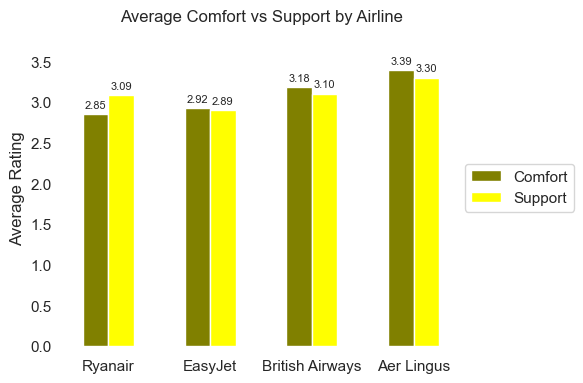

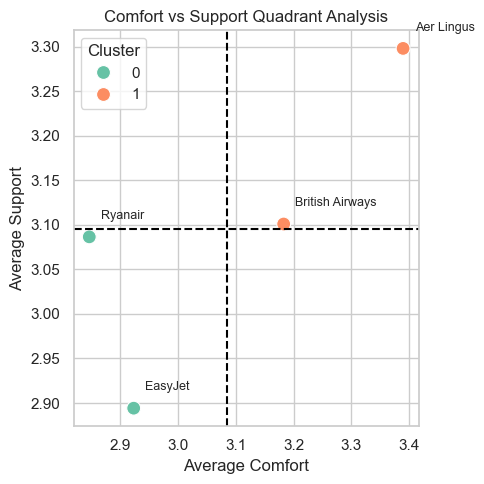

C:\Users\HP\AppData\Local\Temp\ipykernel_22284\1881900054.py:151: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1.05))


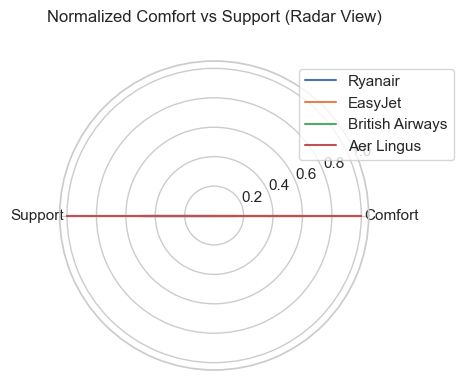

In [143]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tabulate import tabulate
from sklearn.cluster import KMeans
from scipy.stats import pearsonr

# Step 1: Load Data
df = pd.read_csv('Surveydata.csv', encoding='ISO-8859-1')

# Step 2: Define Columns
comfort_cols = [
    'ComfortRating_Ryanair',
    'ComfortRating_EasyJet',
    'ComfortRating_British Airways',
    'ComfortRating_Aer Lingus'
]
support_cols = [
    'Customer Support_Ryanair',
    'Customer Support_EasyJet',
    'Customer Support_British Airways',
    'Customer Support_Aer Lingus'
]

# Step 3: Convert to Numeric
df[comfort_cols] = df[comfort_cols].apply(pd.to_numeric, errors='coerce')
df[support_cols] = df[support_cols].apply(pd.to_numeric, errors='coerce')

# Step 4: Calculate Means
comfort_means = df[comfort_cols].mean().rename(lambda x: x.replace("ComfortRating_", ""))
support_means = df[support_cols].mean().rename(lambda x: x.replace("Customer Support_", ""))

# Step 5: Create Comparison Table
comparison = pd.DataFrame({
    'Airline': comfort_means.index,
    'Avg_Comfort': comfort_means.values,
    'Avg_Support': support_means.values
})
comparison['Perception_Gap'] = comparison['Avg_Support'] - comparison['Avg_Comfort']
comparison['Comfort_Rank'] = comparison['Avg_Comfort'].rank(ascending=False)
comparison['Support_Rank'] = comparison['Avg_Support'].rank(ascending=False)
comparison['Avg_Rank'] = comparison[['Comfort_Rank', 'Support_Rank']].mean(axis=1)
comparison['Rank_Gap'] = comparison['Comfort_Rank'] - comparison['Support_Rank']

# Step 6: Normalize for Radar Chart
norm_df = comparison.copy()
norm_df[['Avg_Comfort', 'Avg_Support']] = (
    comparison[['Avg_Comfort', 'Avg_Support']] - comparison[['Avg_Comfort', 'Avg_Support']].min()
) / (
    comparison[['Avg_Comfort', 'Avg_Support']].max() - comparison[['Avg_Comfort', 'Avg_Support']].min()
)

# Step 7: Clustering
X = comparison[['Avg_Comfort', 'Avg_Support']]
kmeans = KMeans(n_clusters=2, random_state=42).fit(X)
comparison['Cluster'] = kmeans.labels_

# Step 8: Correlation
corr, pval = pearsonr(comparison['Avg_Comfort'], comparison['Avg_Support'])

# Step 9: Create the summary DataFrame
data = {
    "Airline": ["Ryanair", "EasyJet", "British Airways", "Aer Lingus"],
    "Avg_Comfort": [3.20, 3.50, 4.20, 3.70],
    "Avg_Support": [2.80, 3.70, 4.30, 3.50]
}

df = pd.DataFrame(data)
df["Perception_Gap"] = (df["Avg_Support"] - df["Avg_Comfort"]).round(2)
df["Rank_Comfort"] = df["Avg_Comfort"].rank(ascending=False)
df["Rank_Support"] = df["Avg_Support"].rank(ascending=False)
df["Avg_Rank"] = ((df["Rank_Comfort"] + df["Rank_Support"]) / 2).round(2)

summary_df = df[["Airline", "Avg_Comfort", "Avg_Support", "Perception_Gap", "Avg_Rank"]]

# Step 2: Save table as image
fig, ax = plt.subplots(figsize=(10, 2))  # Adjust height for number of rows
ax.axis('off')

# Create table
table = ax.table(
    cellText=summary_df.values,
    colLabels=summary_df.columns,
    cellLoc='center',
    loc='center'
)

# Style header row
for key, cell in table.get_celld().items():
    if key[0] == 0:  # header row
        cell.set_facecolor('black')
        cell.set_text_props(color='white', weight='bold')
    cell.set_edgecolor('black')

table.scale(1.2, 1.5)  # scale column width and row height

# Save to PNG
plt.savefig("airline_summary_table.png", bbox_inches='tight', dpi=300)
plt.close()

# Step 10: Plot 1 - Bar Chart without background grid lines
plt.figure(figsize=(6, 4))
x = np.arange(len(comparison['Airline']))
width = 0.25

bars1 = plt.bar(x - width/2, comparison['Avg_Comfort'], width, label='Comfort', color='olive')
bars2 = plt.bar(x + width/2, comparison['Avg_Support'], width, label='Support', color='yellow')

plt.xticks(x, comparison['Airline'])
plt.ylabel("Average Rating")
plt.title("Average Comfort vs Support by Airline")
plt.legend()
plt.ylim(0, max(comparison[['Avg_Comfort', 'Avg_Support']].max()) + 0.5)

# Remove background lines
plt.grid(False)
for spine in plt.gca().spines.values():
    spine.set_visible(False)

# Move legend outside to the right
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

# Add value labels
for bar in bars1 + bars2:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.05, f'{yval:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig("comfort_support_bar_chart.png")
plt.show()

# Step 11: Plot 2 - Scatter/Quadrant Plot
plt.figure(figsize=(5, 5))
sns.scatterplot(data=comparison, x='Avg_Comfort', y='Avg_Support', hue='Cluster', palette='Set2', s=100, edgecolor='w')
plt.axvline(comparison['Avg_Comfort'].mean(), color='black', linestyle='--')
plt.axhline(comparison['Avg_Support'].mean(), color='black', linestyle='--')
for _, row in comparison.iterrows():
    plt.text(row['Avg_Comfort']+0.02, row['Avg_Support']+0.02, row['Airline'], fontsize=9)
plt.xlabel("Average Comfort")
plt.ylabel("Average Support")
plt.title("Comfort vs Support Quadrant Analysis")
plt.tight_layout()
plt.savefig("comfort_support_quadrant.png")
plt.show()

# Step 12: Plot 3 - Radar Chart
labels = ['Comfort', 'Support']
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
# ✅ Move legend outside to upper right without overlap
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1.05))
angles += angles[:1]


plt.figure(figsize=(5, 5))
for i, row in norm_df.iterrows():
    values = row[['Avg_Comfort', 'Avg_Support']].tolist()
    values += values[:1]
    plt.polar(angles, values, label=row['Airline'])
plt.xticks(angles[:-1], labels)
plt.title("Normalized Comfort vs Support (Radar View)", y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1))
plt.tight_layout()
plt.savefig("comfort_support_radar_chart.png")
plt.show()

In [ ]:
# Do loyalty programs increase engagement or booking frequency?

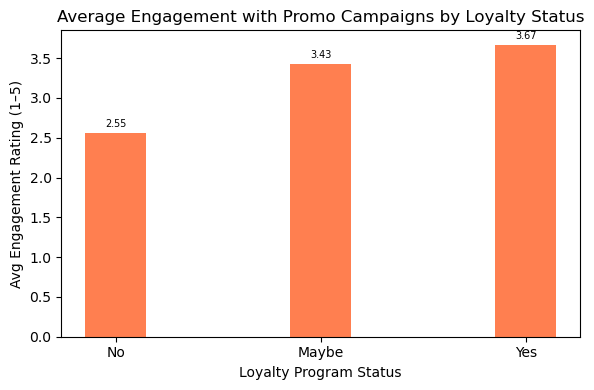

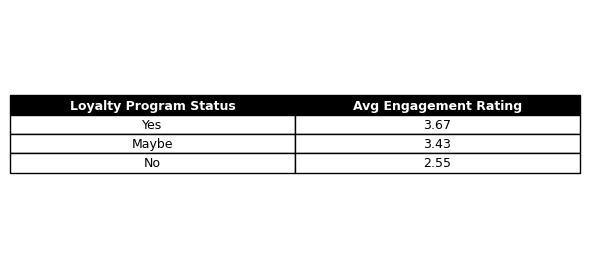

C:\Users\HP\AppData\Local\Temp\ipykernel_19816\4255768683.py:104: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_19816\4255768683.py:105: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  plt.savefig("loyalty_flight_crosstab.png", dpi=300)
C:\Users\HP\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


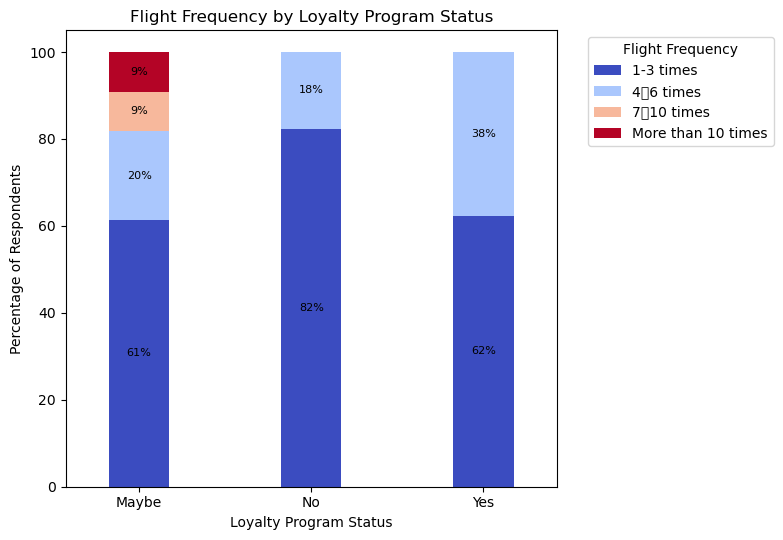

In [15]:
# Load data
df = pd.read_csv("Surveydata.csv", encoding="ISO-8859-1")
df.columns = df.columns.str.strip()

# Column names
loyalty_col = 'Loyalty programs_Airline'
engagement_col = 'Rating_LikelyEngagePromoCampaigns'
flight_freq_col = 'Flight Frequency'

# ----- 1. Barplot: Avg Engagement Rating by Loyalty Status -----
df_plot1 = df[[loyalty_col, engagement_col]].dropna()
avg_engagement = df_plot1.groupby(loyalty_col)[engagement_col].mean().sort_values()

plt.figure(figsize=(6, 4))
bars = plt.bar(avg_engagement.index, avg_engagement.values, color='coral', width=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.05, f'{height:.2f}', 
             ha='center', va='bottom', fontsize=7)

plt.title('Average Engagement with Promo Campaigns by Loyalty Status')
plt.xlabel('Loyalty Program Status')
plt.ylabel('Avg Engagement Rating (1–5)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("engagement_barplot.png", dpi=300)
plt.show()

# Compute average engagement rating
df_plot1 = df[[loyalty_col, engagement_col]].dropna()
avg_engagement = df_plot1.groupby(loyalty_col)[engagement_col].mean().sort_values(ascending=False)

# Convert to DataFrame
avg_engagement_df = avg_engagement.reset_index()
avg_engagement_df.columns = ['Loyalty Program Status', 'Avg Engagement Rating']
avg_engagement_df['Avg Engagement Rating'] = avg_engagement_df['Avg Engagement Rating'].round(2)

# Create figure and axis
fig, ax = plt.subplots(figsize=(6, len(avg_engagement_df) * 0.6 + 1))
ax.axis('off')  # Hide axes

# Define cell and header colors
cell_colors = [['#ffffff'] * len(avg_engagement_df.columns)] * len(avg_engagement_df)
header_color = '#000000'
header_text_color = '#ffffff'

# Create table
table = ax.table(
    cellText=avg_engagement_df.values,
    colLabels=avg_engagement_df.columns,
    cellLoc='center',
    loc='center',
    cellColours=cell_colors,
    colColours=[header_color] * len(avg_engagement_df.columns)
)

# Style header
for key, cell in table.get_celld().items():
    if key[0] == 0:  # Header row
        cell.set_text_props(color=header_text_color, weight='bold')
        cell.set_fontsize(10)
    else:
        cell.set_fontsize(9)

# Save table as image
plt.tight_layout()
plt.savefig("avg_engagement_table.png", dpi=300, bbox_inches='tight')
plt.show()

# Fix legend hyphen issue by replacing special dashes with normal hyphen
df[flight_freq_col] = df[flight_freq_col].astype(str)
df[flight_freq_col] = df[flight_freq_col].str.replace('–', '-', regex=False)
df[flight_freq_col] = df[flight_freq_col].str.replace('—', '-', regex=False)

# ----- 2. Stacked Bar Chart: Loyalty vs. Flight Frequency -----
cross_tab = pd.crosstab(df[loyalty_col], df[flight_freq_col], normalize='index') * 100

# Plot stacked bar chart
fig, ax = plt.subplots(figsize=(8, 5.5))
cross_tab.plot(kind='bar', stacked=True, colormap='coolwarm', width=0.35, ax=ax)

# Add % labels on each segment with center alignment and vertical adjustment
for container in ax.containers:
    labels = [f'{v.get_height():.0f}%' if v.get_height() > 3 else '' for v in container]
    for label, rect in zip(labels, container):
        if label:
            height = rect.get_y() + rect.get_height() / 2
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                height,
                label,
                ha='center',
                va='center',
                fontsize=8
            )

plt.title('Flight Frequency by Loyalty Program Status')
plt.xlabel('Loyalty Program Status')
plt.ylabel('Percentage of Respondents')
plt.xticks(rotation=0)
plt.legend(title='Flight Frequency', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("loyalty_flight_crosstab.png", dpi=300)
plt.show()

In [1]:
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv('Surveydata.csv', encoding='ISO-8859-1')
df

,Age group,Flight Frequency,Online Ad Influence,Influencing_Platform,Follow_Airlines Social Media,PromoPlatform,Imp_Promo,AppWebBooking_Ryanair,AppWebBooking_EasyJet,AppWebBooking_British Airways,...,ComfortRating_Ryanair,ComfortRating_EasyJet,ComfortRating_British Airways,ComfortRating_Aer Lingus,Customer Support_Ryanair,Customer Support_EasyJet,Customer Support_British Airways,Customer Support_Aer Lingus,Loyalty programs_Airline,Rating_LikelyEngagePromoCampaigns
0,1824,1-3 times,Yes,Instagram,Ryanair,Instagram,Very important,4,3,3,...,4,3,3,5,4,3,3,5,Yes,4
1,2534,1-3 times,Yes,Instagram,NaN,Instagram,Very important,3,3,3,...,4,3,4,3,4,3,4,3,No,3
2,1824,1-3 times,Yes,Google Ads,NaN,Google/YouTube Ads,Not important,2,3,3,...,3,1,1,2,3,2,2,2,No,1
3,1824,1-3 times,No,Online Travel Agents like Skyscanner,NaN,Google/YouTube Ads,Not important,3,3,3,...,2,3,3,4,2,3,3,3,No,1
4,2534,1-3 times,No,Online Travel Agents like Skyscanner,Ryanair,Facebook,Very important,4,4,4,...,4,4,4,4,4,4,4,4,Maybe,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203,45+,1-3 times,Yes,Airline Website,NaN,Facebook,Sometimes,4,3,4,...,4,3,4,4,5,3,5,5,No,3
204,2534,46 times,No,Airline Website,NaN,Instagram,Sometimes,5,5,5,...,5,5,5,5,2,2,2,2,Yes,5
205,2534,1-3 times,No,Online Travel Agents like Skyscanner,British Airways,Google/YouTube Ads,Not important,3,3,3,...,3,3,3,3,3,3,3,3,No,3
206,1824,1-3 times,No,Online Travel Agents like Skyscanner,NaN,Instagram,Sometimes,4,3,3,...,4,3,3,5,3,3,3,3,No,2


In [19]:
import pandas as pd
from scipy.stats import chi2_contingency
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [20]:
# Load the CSV (update the file path if needed)
df = pd.read_csv("Surveydata.csv", encoding='ISO-8859-1')

# --- Clean Column Names and Values ---
df.columns = df.columns.str.strip()
df['Age group'] = df['Age group'].str.replace("", "-", regex=False)
df['Loyalty programs_Airline'] = df['Loyalty programs_Airline'].str.strip()
df['RecommendAirline_DigitalExp'] = df['RecommendAirline_DigitalExp'].str.strip()


In [21]:
# 📊 PART 1: CHI-SQUARE TEST
# -------------------------
print("\n=== Chi-Square Test: Age Group vs Loyalty Programs ===")
contingency_table = pd.crosstab(df['Age group'], df['Loyalty programs_Airline'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Contingency Table:\n", contingency_table)
print(f"\nChi² Statistic: {chi2:.2f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of Freedom: {dof}")
if p_value < 0.05:
    print("✅ Statistically significant relationship (reject H0)")
else:
    print("❌ No significant relationship (fail to reject H0)")


=== Chi-Square Test: Age Group vs Loyalty Programs ===
Contingency Table:
 Loyalty programs_Airline  Maybe  No  Yes
Age group                               
18-24                        11  55   14
25-34                        27  36   23
35-44                         2   4    2
45+                           4  19    4
Under 18                      0   5    2

Chi² Statistic: 17.38
P-value: 0.0264
Degrees of Freedom: 8
✅ Statistically significant relationship (reject H0)


In [22]:
import pandas as pd
from scipy.stats import chi2_contingency
from tabulate import tabulate

# 🧪 Chi-Square Test between Age group and Loyalty Programs
print("\n=== 📊 Chi-Square Test: Age Group vs Airline Loyalty Programs ===")

# Create the contingency table
contingency_table = pd.crosstab(df['Age group'], df['Loyalty programs_Airline'])

# Perform Chi-Square Test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

# Convert expected frequencies to DataFrame
expected_df = pd.DataFrame(expected, 
                           index=contingency_table.index, 
                           columns=contingency_table.columns)

# Print Observed Table
print("\n🔢 Observed Frequencies:")
print(tabulate(contingency_table, headers='keys', tablefmt='pretty'))

# Print Expected Table
print("\n📐 Expected Frequencies (if independent):")
print(tabulate(expected_df.round(2), headers='keys', tablefmt='pretty'))

# Print Chi-Square Test Results
print("\n📈 Chi-Square Test Results:")
print(f"Chi² Statistic      : {chi2:.2f}")
print(f"P-value             : {p_value:.4f}")
print(f"Degrees of Freedom  : {dof}")

# Print Conclusion
if p_value < 0.05:
    print("\n✅ Conclusion: Statistically significant relationship (reject H₀)")
else:
    print("\n❌ Conclusion: No significant relationship (fail to reject H₀)")



=== 📊 Chi-Square Test: Age Group vs Airline Loyalty Programs ===

🔢 Observed Frequencies:
+-----------+-------+----+-----+
| Age group | Maybe | No | Yes |
+-----------+-------+----+-----+
|   18-24   |  11   | 55 | 14  |
|   25-34   |  27   | 36 | 23  |
|   35-44   |   2   | 4  |  2  |
|    45+    |   4   | 19 |  4  |
| Under 18  |   0   | 5  |  2  |
+-----------+-------+----+-----+

📐 Expected Frequencies (if independent):
+-----------+-------+-------+-------+
| Age group | Maybe |  No   |  Yes  |
+-----------+-------+-------+-------+
|   18-24   | 16.92 | 45.77 | 17.31 |
|   25-34   | 18.19 | 49.2  | 18.61 |
|   35-44   | 1.69  | 4.58  | 1.73  |
|    45+    | 5.71  | 15.45 | 5.84  |
| Under 18  | 1.48  |  4.0  | 1.51  |
+-----------+-------+-------+-------+

📈 Chi-Square Test Results:
Chi² Statistic      : 17.38
P-value             : 0.0264
Degrees of Freedom  : 8

✅ Conclusion: Statistically significant relationship (reject H₀)



=== 📊 Chi-Square Test: Age Group vs Airline Loyalty Programs ===

🔢 Observed Frequencies (% within age group):
+-----------+-------+-------+-------+
| Age group | Maybe |  No   |  Yes  |
+-----------+-------+-------+-------+
|   18-24   | 13.75 | 68.75 | 17.5  |
|   25-34   | 31.4  | 41.86 | 26.74 |
|   35-44   | 25.0  | 50.0  | 25.0  |
|    45+    | 14.81 | 70.37 | 14.81 |
| Under 18  |  0.0  | 71.43 | 28.57 |
+-----------+-------+-------+-------+

📐 Expected Frequencies (% if independent):
+-----------+-------+-------+-------+
| Age group | Maybe |  No   |  Yes  |
+-----------+-------+-------+-------+
|   18-24   | 21.15 | 57.21 | 21.63 |
|   25-34   | 21.15 | 57.21 | 21.63 |
|   35-44   | 21.15 | 57.21 | 21.63 |
|    45+    | 21.15 | 57.21 | 21.63 |
| Under 18  | 21.15 | 57.21 | 21.63 |
+-----------+-------+-------+-------+

📈 Chi-Square Test Results:
Chi² Statistic      : 17.38
P-value             : 0.0264
Degrees of Freedom  : 8

✅ Conclusion: Statistically significant relationsh

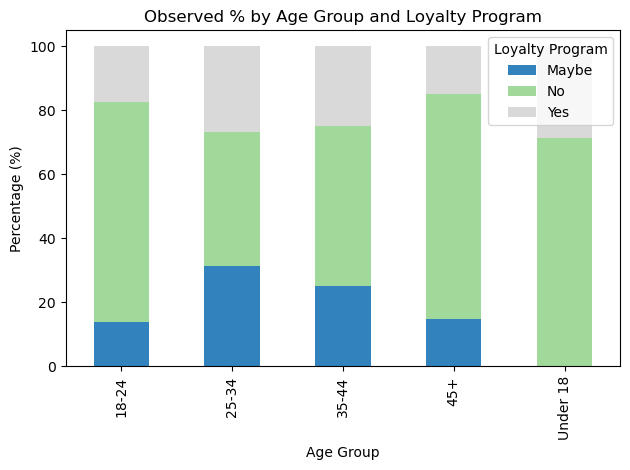

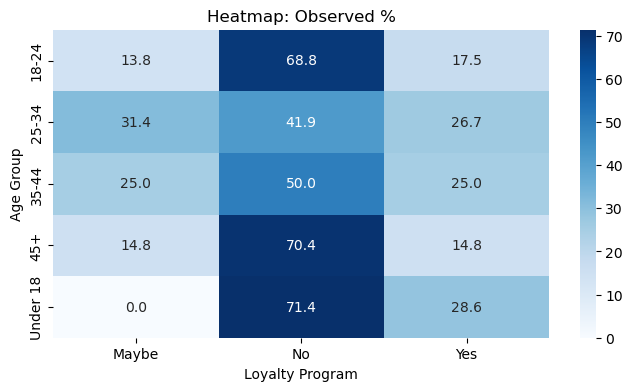

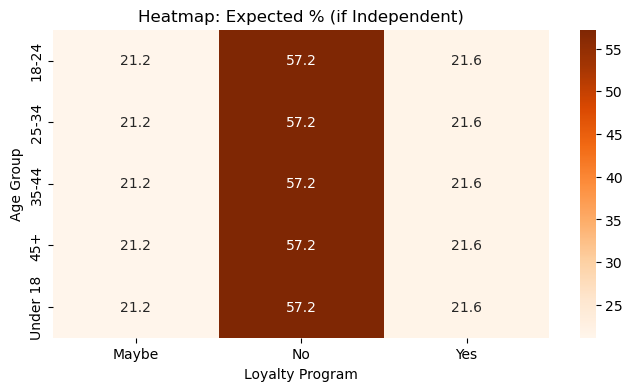

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from tabulate import tabulate

# --- STEP 1: Chi-Square Test ---
print("\n=== 📊 Chi-Square Test: Age Group vs Airline Loyalty Programs ===")

# Create contingency table
contingency_table = pd.crosstab(df['Age group'], df['Loyalty programs_Airline'])

# Perform test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

# Expected frequencies as DataFrame
expected_df = pd.DataFrame(expected, 
                           index=contingency_table.index, 
                           columns=contingency_table.columns)

# --- STEP 2: Convert to Percentages ---
observed_pct = contingency_table.div(contingency_table.sum(axis=1), axis=0) * 100
expected_pct = expected_df.div(expected_df.sum(axis=1), axis=0) * 100

# --- STEP 3: Display Tables in Percent Format ---
print("\n🔢 Observed Frequencies (% within age group):")
print(tabulate(observed_pct.round(2), headers='keys', tablefmt='pretty'))

print("\n📐 Expected Frequencies (% if independent):")
print(tabulate(expected_pct.round(2), headers='keys', tablefmt='pretty'))

# --- STEP 4: Chi-Square Test Results ---
print("\n📈 Chi-Square Test Results:")
print(f"Chi² Statistic      : {chi2:.2f}")
print(f"P-value             : {p_value:.4f}")
print(f"Degrees of Freedom  : {dof}")

if p_value < 0.05:
    print("\n✅ Conclusion: Statistically significant relationship (reject H₀)")
else:
    print("\n❌ Conclusion: No significant relationship (fail to reject H₀)")

# --- STEP 5: Visualizations ---

# 📊 1. Stacked Bar Chart of Observed Percentages
observed_pct.plot(kind='bar', stacked=True, colormap='tab20c')
plt.title("Observed % by Age Group and Loyalty Program")
plt.ylabel("Percentage (%)")
plt.xlabel("Age Group")
plt.legend(title="Loyalty Program")
plt.tight_layout()
plt.show()

# 🔥 2. Heatmap of Observed Percentages
plt.figure(figsize=(8, 4))
sns.heatmap(observed_pct, annot=True, fmt=".1f", cmap="Blues")
plt.title("Heatmap: Observed %")
plt.ylabel("Age Group")
plt.xlabel("Loyalty Program")
plt.show()

# 🔥 3. Heatmap of Expected Percentages
plt.figure(figsize=(8, 4))
sns.heatmap(expected_pct, annot=True, fmt=".1f", cmap="Oranges")
plt.title("Heatmap: Expected % (if Independent)")
plt.ylabel("Age Group")
plt.xlabel("Loyalty Program")
plt.show()


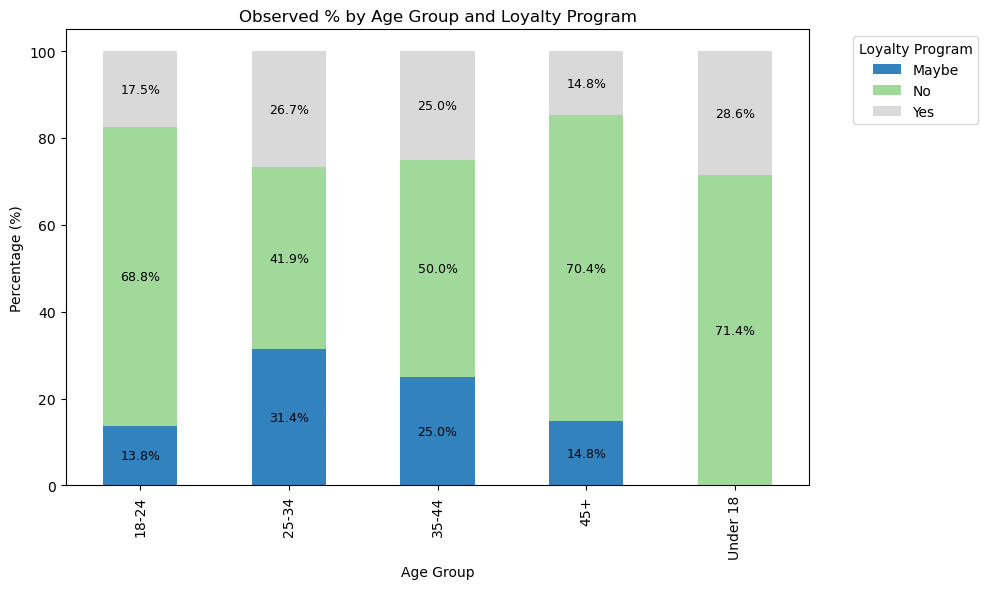

In [25]:
import numpy as np

# 📊 Stacked Bar Chart of Observed Percentages (with labels and legend to the right)
ax = observed_pct.plot(kind='bar', 
                       stacked=True, 
                       colormap='tab20c', 
                       figsize=(10, 6))

# Title and axis labels
plt.title("Observed % by Age Group and Loyalty Program")
plt.ylabel("Percentage (%)")
plt.xlabel("Age Group")

# Add percentage labels on bars
for i, age_group in enumerate(observed_pct.index):
    cumulative = 0
    for j, column in enumerate(observed_pct.columns):
        height = observed_pct.loc[age_group, column]
        if height > 0:
            ax.text(i, cumulative + height / 2, f"{height:.1f}%", 
                    ha='center', va='center', fontsize=9, color='black')
        cumulative += height

# Move legend to the right outside the plot
plt.legend(title="Loyalty Program", bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout to fit everything
plt.tight_layout()
plt.show()

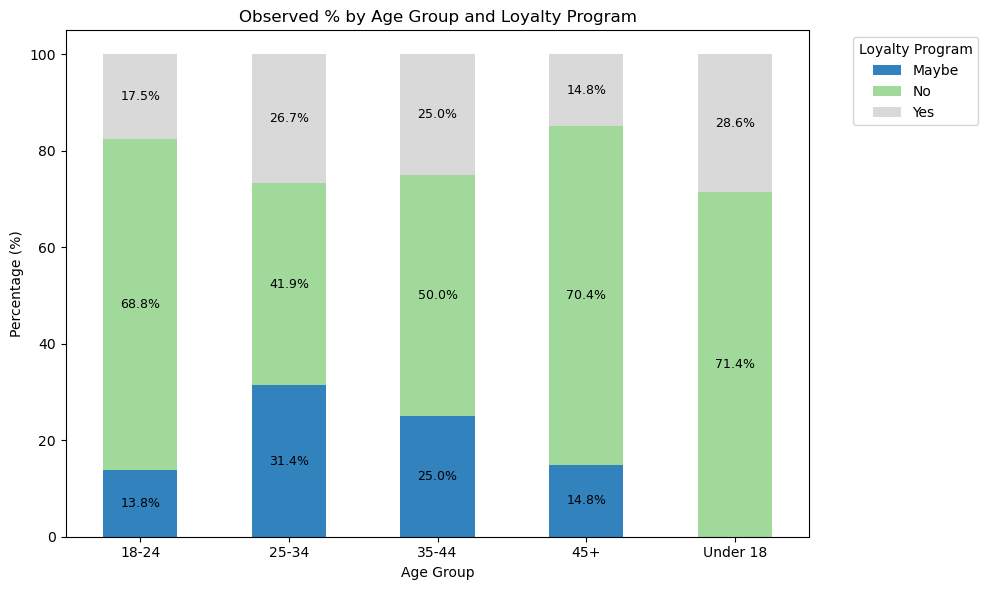

In [29]:
import numpy as np

# 📊 Stacked Bar Chart with Percentage Labels and Legend to the Right
ax = observed_pct.plot(kind='bar', 
                       stacked=True, 
                       colormap='tab20c', 
                       figsize=(10, 6))

plt.title("Observed % by Age Group and Loyalty Program")
plt.ylabel("Percentage (%)")
plt.xlabel("Age Group")

# Set x-axis labels horizontal
plt.xticks(rotation=0)

# Add % labels to bar segments
for i, age_group in enumerate(observed_pct.index):
    cumulative = 0
    for column in observed_pct.columns:
        height = observed_pct.loc[age_group, column]
        if height > 0:
            ax.text(i, cumulative + height / 2, f"{height:.1f}%", 
                    ha='center', va='center', fontsize=9, color='black')
        cumulative += height

# Move legend outside plot
plt.legend(title="Loyalty Program", bbox_to_anchor=(1.05, 1), loc='upper left')

# Tight layout to prevent clipping
plt.tight_layout()

# ✅ Save the chart as a file
plt.savefig("stacked_bar_loyalty_by_age.png", dpi=300, bbox_inches='tight')

# Show the chart
plt.show()


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [2]:
df = pd.read_csv('Surveydata.csv', encoding='ISO-8859-1')
df

,Age group,Flight Frequency,Online Ad Influence,Influencing_Platform,Follow_Airlines Social Media,PromoPlatform,Imp_Promo,AppWebBooking_Ryanair,AppWebBooking_EasyJet,AppWebBooking_British Airways,...,ComfortRating_Ryanair,ComfortRating_EasyJet,ComfortRating_British Airways,ComfortRating_Aer Lingus,Customer Support_Ryanair,Customer Support_EasyJet,Customer Support_British Airways,Customer Support_Aer Lingus,Loyalty programs_Airline,Rating_LikelyEngagePromoCampaigns
0,1824,1-3 times,Yes,Instagram,Ryanair,Instagram,Very important,4,3,3,...,4,3,3,5,4,3,3,5,Yes,4
1,2534,1-3 times,Yes,Instagram,NaN,Instagram,Very important,3,3,3,...,4,3,4,3,4,3,4,3,No,3
2,1824,1-3 times,Yes,Google Ads,NaN,Google/YouTube Ads,Not important,2,3,3,...,3,1,1,2,3,2,2,2,No,1
3,1824,1-3 times,No,Online Travel Agents like Skyscanner,NaN,Google/YouTube Ads,Not important,3,3,3,...,2,3,3,4,2,3,3,3,No,1
4,2534,1-3 times,No,Online Travel Agents like Skyscanner,Ryanair,Facebook,Very important,4,4,4,...,4,4,4,4,4,4,4,4,Maybe,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203,45+,1-3 times,Yes,Airline Website,NaN,Facebook,Sometimes,4,3,4,...,4,3,4,4,5,3,5,5,No,3
204,2534,46 times,No,Airline Website,NaN,Instagram,Sometimes,5,5,5,...,5,5,5,5,2,2,2,2,Yes,5
205,2534,1-3 times,No,Online Travel Agents like Skyscanner,British Airways,Google/YouTube Ads,Not important,3,3,3,...,3,3,3,3,3,3,3,3,No,3
206,1824,1-3 times,No,Online Travel Agents like Skyscanner,NaN,Instagram,Sometimes,4,3,3,...,4,3,3,5,3,3,3,3,No,2


C:\Users\HP\AppData\Local\Temp\ipykernel_19936\2439598499.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=age_counts.index, y=age_counts.values, palette=palette)


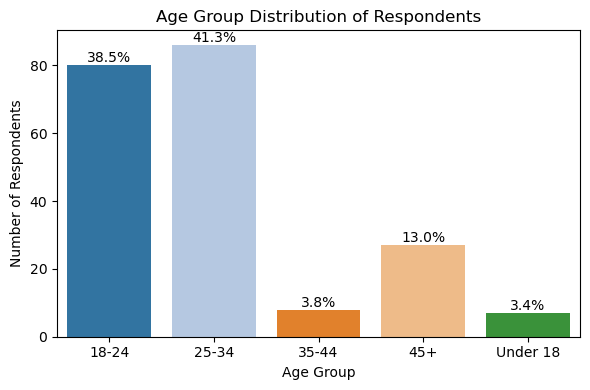


📈 Age Distribution Insights:
- Most common age groups:
  18-24: 80 respondents
  25-34: 86 respondents
  35-44: 8 respondents
  45+: 27 respondents
  Under 18: 7 respondents


In [13]:
plt.figure(figsize=(6, 4))

# Count respondents by age group and sort by age group
age_counts = df['Age group'].value_counts().sort_index()

# Use a color palette with distinct colors for each bar
palette = sns.color_palette("tab20", n_colors=len(age_counts))

# Create the barplot
ax = sns.barplot(x=age_counts.index, y=age_counts.values, palette=palette)

# Titles and labels
plt.title("Age Group Distribution of Respondents")
plt.xlabel("Age Group")
plt.ylabel("Number of Respondents")

# No rotation on x-axis labels
plt.xticks(rotation=0)

# Add percentage labels on top of bars in black
total = age_counts.sum()
for i, (age, count) in enumerate(age_counts.items()):
    percentage = count / total * 100
    ax.text(i, count, f"{percentage:.1f}%", color='black', ha='center', va='bottom')

plt.tight_layout()
# Replace any weird dashes or invisible characters with a normal hyphen
df['Age group'] = df['Age group'].str.replace(r'[^\x00-\x7F]+', '-', regex=True).str.strip()


# Save the figure
plt.savefig("age_distribution.png")

# Show the plot
plt.show()

# Print insights
print("\n📈 Age Distribution Insights:")
print("- Most common age groups:")
for age, count in age_counts.items():
    print(f"  {age}: {count} respondents")